In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

Value of E= 0.7140
Value of E= -0.6940
Value of E= 0.6960
Value of E= 0.7000
CHSH S = 2.8040
Classical bound: 2.0000
Tsirelson bound: 2.8284


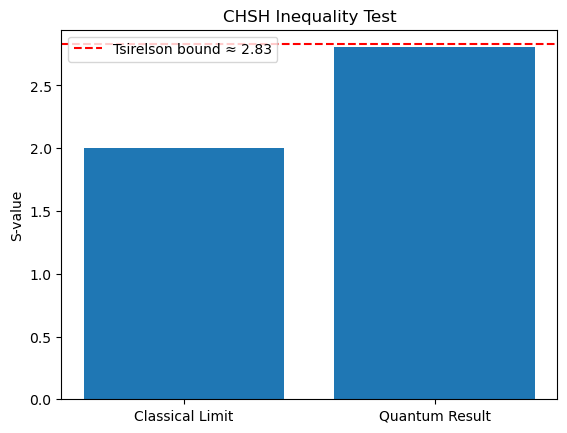

In [11]:
#CHSH Inequality Test with CHSH Histogram
simulator=AerSimulator()
shots=1000

def Bell(theta_1,theta_2,simulator,shots=shots,verbose=False):
    theta_1 = (np.pi/180)*theta_1
    theta_2 = (np.pi/180)*theta_2

    
    qc=QuantumCircuit(2,2)
    qc.h(0)
    qc.cx(0,1)
    qc.ry(-2*theta_1,0)
    qc.ry(-2*theta_2,1)
    qc.measure(0,0)
    qc.measure(1,1)
    
    counts=simulator.run(qc,shots=shots,).result().get_counts()
    
    N00=counts.get('00',0)
    N01=counts.get('01',0)
    N10=counts.get('10',0)
    N11=counts.get('11',0)
    
    E=(N00+N11-N01-N10)/shots
   
    if verbose:
        print(f'Value of E= {E:.4f}')
    return E

    
E_a_b = Bell(0, 22.5,simulator, verbose=True)
E_a_bp = Bell(0, 67.5,simulator, verbose=True)
E_ap_b = Bell(45, 22.5,simulator, verbose=True)
E_ap_bp = Bell(45, 67.5,simulator, verbose=True)

s = E_a_b - E_a_bp + E_ap_b + E_ap_bp 

print(f'CHSH S = {s:.4f}')
print(f'Classical bound: 2.0000')
print(f'Tsirelson bound: {2*np.sqrt(2):.4f}')

plt.bar(['Classical Limit', 'Quantum Result'], [2.0, s])
plt.title('CHSH Inequality Test')
tsirelson = 2 * np.sqrt(2)
plt.axhline(tsirelson, color='red', linestyle='--', label=f'Tsirelson bound ≈ {tsirelson:.2f}')
plt.legend()
plt.ylabel('S-value')
plt.savefig("chsh_bar_chart.png", dpi=150, bbox_inches='tight')
plt.show()